# Hindi Digit Recognition — All Three Approaches

| Approach | Method | Key idea |
|----------|--------|----------|
| 1 | Whisper (tiny) fine-tuned | Seq2seq transcription → keyword match; frozen encoder |
| 2 | Wav2Vec2 + classifier head | Pre-computed embeddings cached; only head trained |
| 3 | MFCC + 2D CNN | MFCC + Δ + ΔΔ features fed to a small ConvNet |

> **Pre-requisite:** run `augment_dataset.py` once to create `dataset_split.json` and the augmented WAV files.

In [6]:
# Install dependencies (run once)
# !pip install transformers torch torchaudio librosa soundfile scikit-learn matplotlib seaborn

---
## Shared imports & utilities

In [6]:
import os
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ORIGINAL_PATH = "SMAI Dataset (wav)"
AUG_PATH      = "SMAI Dataset (wav) - Augmented"
SPLIT_FILE    = "dataset_split.json"
NUM_CLASSES   = 11   # 0-9 digits + 10 = unknown
SAMPLE_RATE   = 16000


def load_split():
    assert os.path.exists(SPLIT_FILE), f"Run augment_dataset.py first to create {SPLIT_FILE}"
    with open(SPLIT_FILE) as f:
        return json.load(f)


def get_augmented_files(num_classes=NUM_CLASSES):
    files, labels = [], []
    for d in range(num_classes):
        folder = os.path.join(AUG_PATH, str(d))
        if not os.path.exists(folder):
            continue
        for f in sorted(os.listdir(folder)):
            if f.endswith(".wav"):
                files.append(os.path.join(folder, f))
                labels.append(d)
    return files, labels


def plot_training(train_losses, val_accs, best_epoch, best_acc, cm, title, save_path):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(train_losses, color="steelblue")
    axes[0].axvline(best_epoch - 1, color="red", linestyle="--", label=f"best epoch {best_epoch}")
    axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(val_accs, color="darkorange")
    axes[1].axvline(best_epoch - 1, color="red", linestyle="--", label=f"best acc {best_acc:.2%}")
    axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch")
    axes[1].set_ylim(0, 1); axes[1].legend()

    tick_labels = list(range(10)) + ["unk"]
    sns.heatmap(cm, annot=True, fmt="d", ax=axes[2],
                xticklabels=tick_labels[:NUM_CLASSES],
                yticklabels=tick_labels[:NUM_CLASSES], cmap="Blues")
    axes[2].set_title(f"Confusion Matrix  (acc={best_acc:.2%})")
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")

    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")


split = load_split()
aug_files, aug_labels = get_augmented_files()
print(f"Split loaded. Train orig: {len(split['train'])}  Aug: {len(aug_files)}  Test: {len(split['test'])}")

Split loaded. Train orig: 624  Aug: 3120  Test: 157


---
## Approach 1 — Fine-tuned Whisper (tiny)

Strategy: fine-tune only the **decoder** of `openai/whisper-tiny` (encoder frozen).  
Predicted transcription is matched against Hindi digit keywords; unmatched → class 10 (unknown).

In [8]:
# ── Approach 1 config ─────────────────────────────────────────
A1_MODEL_ID  = "openai/whisper-tiny"
A1_MODEL_DIR = "approach1_whisper_finetuned"
A1_BATCH     = 8
A1_EPOCHS    = 4
A1_LR        = 5e-5
A1_PATIENCE  = 2

DIGIT_TO_HINDI = {
    0: "शून्य", 1: "एक",  2: "दो",  3: "तीन", 4: "चार",
    5: "पाँच",  6: "छह",  7: "सात", 8: "आठ",  9: "नौ",
}

DIGIT_KEYWORDS = {
    0: ["शून्य", "zero", "0", "shunya", "sunya"],
    1: ["एक",   "one",  "1", "ek"],
    2: ["दो",   "two",  "2", "do"],
    3: ["तीन",  "three","3", "teen", "tin"],
    4: ["चार",  "four", "4", "char", "chaar"],
    5: ["पाँच", "five", "5", "panch", "paanch", "पांच"],
    6: ["छह",   "six",  "6", "chhe", "chhah", "छः"],
    7: ["सात",  "seven","7", "saat", "sat"],
    8: ["आठ",   "eight","8", "aath", "ath"],
    9: ["नौ",   "nine", "9", "nau",  "no"],
}

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import WhisperForConditionalGeneration, WhisperProcessor, logging as hf_logging

hf_logging.set_verbosity_error()


def _clean_generation_config(model):
    cfg = model.generation_config
    cfg.max_length            = None
    cfg.forced_decoder_ids    = None
    cfg.suppress_tokens       = None
    cfg.begin_suppress_tokens = None


def match_transcription(text: str) -> int:
    t = text.lower().strip()
    for digit, kws in DIGIT_KEYWORDS.items():
        for kw in kws:
            if kw.lower() in t:
                return digit
    return -1


class WhisperDigitDataset(Dataset):
    def __init__(self, files, labels, processor):
        self.files, self.labels, self.proc = files, labels, processor
        _UNKNOWN_HINDI = "अज्ञात"
        self.label_ids = [
            processor.tokenizer(
                DIGIT_TO_HINDI.get(int(l), _UNKNOWN_HINDI),
                return_tensors="pt", add_special_tokens=True
            ).input_ids[0]
            for l in labels
        ]

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        audio, _ = librosa.load(self.files[idx], sr=SAMPLE_RATE)
        feats = self.proc.feature_extractor(
            audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
        ).input_features[0]
        return feats, self.label_ids[idx]


def a1_collate_fn(batch):
    feats  = torch.stack([b[0] for b in batch])
    labels = [b[1] for b in batch]
    max_l  = max(l.shape[0] for l in labels)
    padded = torch.full((len(labels), max_l), -100, dtype=torch.long)
    for i, l in enumerate(labels):
        padded[i, :l.shape[0]] = l
    return feats, padded


def a1_evaluate(model, processor, test_files, test_labels, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for fpath, label in zip(test_files, test_labels):
            audio, _ = librosa.load(fpath, sr=SAMPLE_RATE)
            enc = processor.feature_extractor(
                audio, sampling_rate=SAMPLE_RATE,
                return_tensors="pt", return_attention_mask=True)
            gen_ids = model.generate(
                enc.input_features.to(device),
                attention_mask=enc.attention_mask.to(device),
                language="hi", task="transcribe", max_new_tokens=15)
            text = processor.tokenizer.batch_decode(
                gen_ids, skip_special_tokens=True,
                clean_up_tokenization_spaces=False)[0]
            pred = match_transcription(text)
            preds.append(pred if pred != -1 else 10)
            trues.append(int(label))
    return trues, preds

In [10]:
# ── Approach 1: Training ──────────────────────────────────────
device_a1 = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device_a1}")

train_files_a1  = split["train"]        + aug_files
train_labels_a1 = split["train_labels"] + aug_labels
test_files_a1   = split["test"]
test_labels_a1  = split["test_labels"]
print(f"Train: {len(train_files_a1)}  Test: {len(test_files_a1)}")

print(f"Loading {A1_MODEL_ID} …")
processor_a1 = WhisperProcessor.from_pretrained(A1_MODEL_ID, language="Hindi", task="transcribe")
processor_a1.tokenizer.clean_up_tokenization_spaces = False
model_a1     = WhisperForConditionalGeneration.from_pretrained(A1_MODEL_ID).to(device_a1)
_clean_generation_config(model_a1)

for p in model_a1.model.encoder.parameters():
    p.requires_grad = False

train_ds_a1 = WhisperDigitDataset(train_files_a1, train_labels_a1, processor_a1)
train_dl_a1 = DataLoader(train_ds_a1, A1_BATCH, shuffle=True,
                         collate_fn=a1_collate_fn, num_workers=0)

trainable_a1 = [p for p in model_a1.parameters() if p.requires_grad]
optimizer_a1 = torch.optim.AdamW(trainable_a1, lr=A1_LR, weight_decay=0.01)
scheduler_a1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_a1, T_max=A1_EPOCHS)

os.makedirs(A1_MODEL_DIR, exist_ok=True)
train_losses_a1, val_accs_a1 = [], []
best_acc_a1, no_improve_a1, best_epoch_a1 = 0.0, 0, 0

for epoch in range(1, A1_EPOCHS + 1):
    model_a1.train()
    total_loss = 0.0
    for feats, lbl_ids in train_dl_a1:
        feats, lbl_ids = feats.to(device_a1), lbl_ids.to(device_a1)
        optimizer_a1.zero_grad()
        loss = model_a1(input_features=feats, labels=lbl_ids).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_a1.parameters(), 1.0)
        optimizer_a1.step()
        total_loss += loss.item()
    scheduler_a1.step()

    avg_loss = total_loss / len(train_dl_a1)
    train_losses_a1.append(avg_loss)

    trues, preds = a1_evaluate(model_a1, processor_a1, test_files_a1, test_labels_a1, device_a1)
    acc = accuracy_score(trues, preds)
    val_accs_a1.append(acc)
    print(f"Epoch {epoch:3d}/{A1_EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {acc:.4f}", end="")

    if acc > best_acc_a1:
        best_acc_a1, best_epoch_a1, no_improve_a1 = acc, epoch, 0
        model_a1.save_pretrained(A1_MODEL_DIR)
        print("  ✓ best saved")
    else:
        no_improve_a1 += 1
        print(f"  (no improve {no_improve_a1}/{A1_PATIENCE})")
        if no_improve_a1 >= A1_PATIENCE:
            print(f"\nEarly stopping. Best: epoch {best_epoch_a1}, acc {best_acc_a1:.4f}")
            break

Device: mps
Train: 3744  Test: 157
Loading openai/whisper-tiny …


Loading weights: 100%|██████████| 167/167 [00:00<00:00, 7941.42it/s]


Epoch   1/4 | Loss: 0.1098 | Val Acc: 0.9682

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.20it/s]


  ✓ best saved
Epoch   2/4 | Loss: 0.0133 | Val Acc: 0.9618  (no improve 1/2)
Epoch   3/4 | Loss: 0.0037 | Val Acc: 0.9554  (no improve 2/2)

Early stopping. Best: epoch 1, acc 0.9682


Loading weights: 100%|██████████| 167/167 [00:00<00:00, 5691.42it/s]


Final Val Accuracy: 0.9682
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        12
           2       0.92      1.00      0.96        12
           3       1.00      1.00      1.00        12
           4       1.00      1.00      1.00        12
           5       1.00      1.00      1.00        12
           6       1.00      0.92      0.96        12
           7       0.92      1.00      0.96        12
           8       1.00      1.00      1.00        12
           9       1.00      0.83      0.91        12
     unknown       0.92      0.95      0.93        37

    accuracy                           0.97       157
   macro avg       0.98      0.97      0.97       157
weighted avg       0.97      0.97      0.97       157



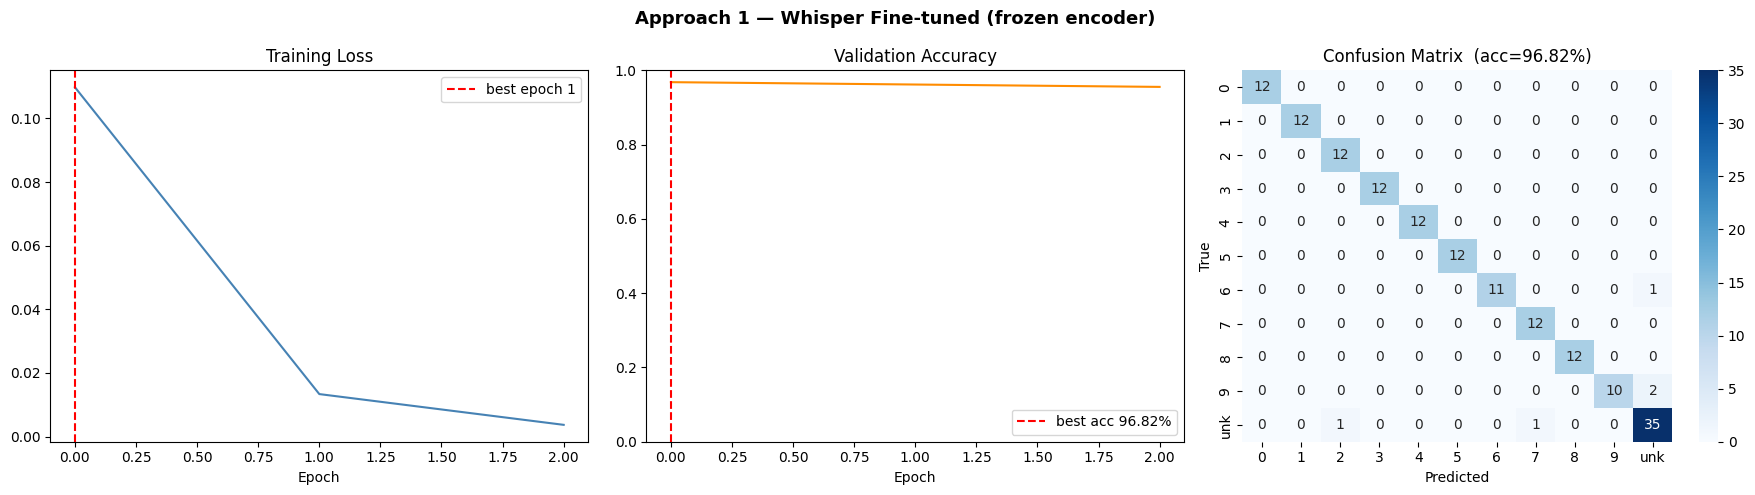

Saved: approach1_results.png


In [11]:
# ── Approach 1: Evaluation & Plots ───────────────────────────
model_a1 = WhisperForConditionalGeneration.from_pretrained(A1_MODEL_DIR).to(device_a1)
_clean_generation_config(model_a1)
trues_a1, preds_a1 = a1_evaluate(model_a1, processor_a1, test_files_a1, test_labels_a1, device_a1)

print("=" * 50)
print(f"Final Val Accuracy: {accuracy_score(trues_a1, preds_a1):.4f}")
target_names = [str(i) for i in range(10)] + ["unknown"]
print(classification_report(trues_a1, preds_a1,
                            labels=list(range(NUM_CLASSES)),
                            target_names=target_names[:NUM_CLASSES],
                            zero_division=0))

cm_a1 = confusion_matrix(trues_a1, preds_a1, labels=list(range(NUM_CLASSES)))
plot_training(train_losses_a1, val_accs_a1, best_epoch_a1, best_acc_a1,
              cm_a1, "Approach 1 — Whisper Fine-tuned (frozen encoder)",
              "approach1_results.png")

---
## Approach 2 — Wav2Vec2 + Classifier Head

Strategy: extract mean-pooled embeddings from a **frozen** `facebook/wav2vec2-base` encoder (cached to disk), then train a small MLP head.

In [12]:
# ── Approach 2 config ─────────────────────────────────────────
A2_MODEL_ID   = "facebook/wav2vec2-base"
A2_MODEL_SAVE = "approach2_model.pt"
A2_TRAIN_CACHE = "approach2_train_cache.pt"
A2_TEST_CACHE  = "approach2_test_cache.pt"
A2_MAX_AUDIO  = 32000   # 2 s
A2_BATCH      = 64
A2_EPOCHS     = 150
A2_LR         = 1e-3
A2_PATIENCE   = 20

In [13]:
import torch.nn as nn
from torch.utils.data import TensorDataset
from transformers import Wav2Vec2Processor, Wav2Vec2Model


class DigitHead(nn.Module):
    def __init__(self, input_dim=768, num_classes=NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )
    def forward(self, x): return self.net(x)


def extract_embeddings_a2(files, labels, processor, encoder, device, cache_path):
    if os.path.exists(cache_path):
        print(f"  Loading cache → {cache_path}")
        d = torch.load(cache_path, map_location="cpu")
        return d["emb"], d["labels"]

    print(f"  Extracting {len(files)} embeddings (one-time, then cached) …")
    encoder.eval()
    embs, lbls = [], []
    for i, (fpath, lbl) in enumerate(zip(files, labels)):
        audio, _ = librosa.load(fpath, sr=SAMPLE_RATE)
        if len(audio) < A2_MAX_AUDIO:
            audio = np.pad(audio, (0, A2_MAX_AUDIO - len(audio)))
        else:
            audio = audio[:A2_MAX_AUDIO]
        inp = processor(audio, sampling_rate=SAMPLE_RATE, return_tensors="pt", padding=False)
        with torch.no_grad():
            hidden = encoder(inp.input_values.to(device)).last_hidden_state.mean(dim=1)
        embs.append(hidden.cpu())
        lbls.append(int(lbl))
        if (i + 1) % 100 == 0 or (i + 1) == len(files):
            print(f"    {i+1}/{len(files)}")

    emb_t = torch.cat(embs, dim=0)
    lbl_t = torch.LongTensor(lbls)
    torch.save({"emb": emb_t, "labels": lbl_t}, cache_path)
    print(f"  Saved cache → {cache_path}")
    return emb_t, lbl_t


def a2_evaluate(head, loader, device):
    head.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, y in loader:
            preds += head(X.to(device)).argmax(1).cpu().tolist()
            trues += y.tolist()
    return trues, preds

In [14]:
# ── Approach 2: Extract embeddings ───────────────────────────
device_a2 = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device_a2}")

train_files_a2  = split["train"]        + aug_files
train_labels_a2 = split["train_labels"] + aug_labels
test_files_a2   = split["test"]
test_labels_a2  = split["test_labels"]

print(f"Loading encoder from {A2_MODEL_ID} …")
processor_a2 = Wav2Vec2Processor.from_pretrained(A2_MODEL_ID)
encoder_a2   = Wav2Vec2Model.from_pretrained(A2_MODEL_ID).to(device_a2)
for p in encoder_a2.parameters():
    p.requires_grad = False

print("Train embeddings:")
train_emb, train_lbl = extract_embeddings_a2(
    train_files_a2, train_labels_a2, processor_a2, encoder_a2, device_a2, A2_TRAIN_CACHE)
print("Test embeddings:")
test_emb, test_lbl = extract_embeddings_a2(
    test_files_a2, test_labels_a2, processor_a2, encoder_a2, device_a2, A2_TEST_CACHE)

del encoder_a2
if device_a2.type == "mps":  torch.mps.empty_cache()
elif device_a2.type == "cuda": torch.cuda.empty_cache()
print(f"Embedding shapes — train: {train_emb.shape}  test: {test_emb.shape}")

Device: mps
Loading encoder from facebook/wav2vec2-base …


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 66232.46it/s]


Train embeddings:
  Extracting 3744 embeddings (one-time, then cached) …
    100/3744
    200/3744
    300/3744
    400/3744
    500/3744
    600/3744
    700/3744
    800/3744
    900/3744
    1000/3744
    1100/3744
    1200/3744
    1300/3744
    1400/3744
    1500/3744
    1600/3744
    1700/3744
    1800/3744
    1900/3744
    2000/3744
    2100/3744
    2200/3744
    2300/3744
    2400/3744
    2500/3744
    2600/3744
    2700/3744
    2800/3744
    2900/3744
    3000/3744
    3100/3744
    3200/3744
    3300/3744
    3400/3744
    3500/3744
    3600/3744
    3700/3744
    3744/3744
  Saved cache → approach2_train_cache.pt
Test embeddings:
  Extracting 157 embeddings (one-time, then cached) …
    100/157
    157/157
  Saved cache → approach2_test_cache.pt
Embedding shapes — train: torch.Size([3744, 768])  test: torch.Size([157, 768])


In [15]:
# ── Approach 2: Training ──────────────────────────────────────
train_dl_a2 = DataLoader(TensorDataset(train_emb, train_lbl), A2_BATCH, shuffle=True)
test_dl_a2  = DataLoader(TensorDataset(test_emb,  test_lbl),  A2_BATCH)

head_a2      = DigitHead(num_classes=NUM_CLASSES).to(device_a2)
optimizer_a2 = torch.optim.Adam(head_a2.parameters(), lr=A2_LR)
scheduler_a2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_a2, T_max=A2_EPOCHS)
criterion_a2 = nn.CrossEntropyLoss()

train_losses_a2, val_accs_a2 = [], []
best_acc_a2, no_improve_a2, best_epoch_a2 = 0.0, 0, 0

for epoch in range(1, A2_EPOCHS + 1):
    head_a2.train()
    total_loss = 0.0
    for X, y in train_dl_a2:
        X, y = X.to(device_a2), y.to(device_a2)
        optimizer_a2.zero_grad()
        loss = criterion_a2(head_a2(X), y)
        loss.backward(); optimizer_a2.step()
        total_loss += loss.item()
    scheduler_a2.step()

    trues, preds = a2_evaluate(head_a2, test_dl_a2, device_a2)
    acc      = accuracy_score(trues, preds)
    avg_loss = total_loss / len(train_dl_a2)
    train_losses_a2.append(avg_loss)
    val_accs_a2.append(acc)
    print(f"Epoch {epoch:3d}/{A2_EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {acc:.4f}", end="")

    if acc > best_acc_a2:
        best_acc_a2, best_epoch_a2, no_improve_a2 = acc, epoch, 0
        torch.save(head_a2.state_dict(), A2_MODEL_SAVE)
        print("  ✓ best saved")
    else:
        no_improve_a2 += 1
        print(f"  (no improve {no_improve_a2}/{A2_PATIENCE})")
        if no_improve_a2 >= A2_PATIENCE:
            print(f"\nEarly stopping. Best: epoch {best_epoch_a2}, acc {best_acc_a2:.4f}")
            break

Epoch   1/150 | Loss: 1.9586 | Val Acc: 0.4331  ✓ best saved
Epoch   2/150 | Loss: 1.4297 | Val Acc: 0.5732  ✓ best saved
Epoch   3/150 | Loss: 1.1910 | Val Acc: 0.6051  ✓ best saved
Epoch   4/150 | Loss: 1.0537 | Val Acc: 0.6433  ✓ best saved
Epoch   5/150 | Loss: 0.9563 | Val Acc: 0.6752  ✓ best saved
Epoch   6/150 | Loss: 0.8800 | Val Acc: 0.6815  ✓ best saved
Epoch   7/150 | Loss: 0.8073 | Val Acc: 0.7197  ✓ best saved
Epoch   8/150 | Loss: 0.7552 | Val Acc: 0.7134  (no improve 1/20)
Epoch   9/150 | Loss: 0.7043 | Val Acc: 0.7452  ✓ best saved
Epoch  10/150 | Loss: 0.6563 | Val Acc: 0.7898  ✓ best saved
Epoch  11/150 | Loss: 0.6260 | Val Acc: 0.7580  (no improve 1/20)
Epoch  12/150 | Loss: 0.5889 | Val Acc: 0.7898  (no improve 2/20)
Epoch  13/150 | Loss: 0.5556 | Val Acc: 0.7707  (no improve 3/20)
Epoch  14/150 | Loss: 0.5320 | Val Acc: 0.8025  ✓ best saved
Epoch  15/150 | Loss: 0.5077 | Val Acc: 0.7898  (no improve 1/20)
Epoch  16/150 | Loss: 0.4829 | Val Acc: 0.7898  (no improve 

Final Val Accuracy: 0.8471
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.83      0.91        12
           2       1.00      0.92      0.96        12
           3       0.92      1.00      0.96        12
           4       0.79      0.92      0.85        12
           5       0.83      0.83      0.83        12
           6       0.92      1.00      0.96        12
           7       0.56      0.75      0.64        12
           8       0.82      0.75      0.78        12
           9       0.80      0.67      0.73        12
     unknown       0.85      0.78      0.82        37

    accuracy                           0.85       157
   macro avg       0.86      0.86      0.85       157
weighted avg       0.86      0.85      0.85       157



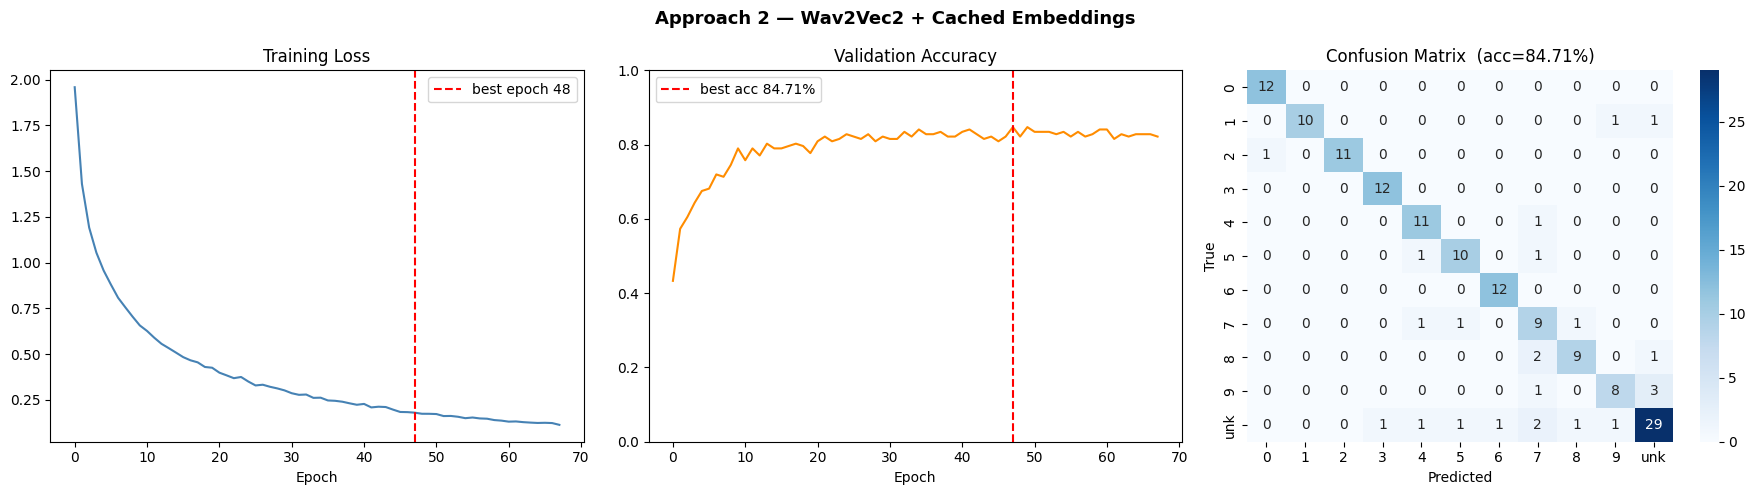

Saved: approach2_results.png


In [16]:
# ── Approach 2: Evaluation & Plots ───────────────────────────
head_a2.load_state_dict(torch.load(A2_MODEL_SAVE, map_location=device_a2))
trues_a2, preds_a2 = a2_evaluate(head_a2, test_dl_a2, device_a2)

print("=" * 50)
print(f"Final Val Accuracy: {accuracy_score(trues_a2, preds_a2):.4f}")
print(classification_report(trues_a2, preds_a2,
                            target_names=target_names[:NUM_CLASSES],
                            labels=list(range(NUM_CLASSES)),
                            zero_division=0))

cm_a2 = confusion_matrix(trues_a2, preds_a2, labels=list(range(NUM_CLASSES)))
plot_training(train_losses_a2, val_accs_a2, best_epoch_a2, best_acc_a2,
              cm_a2, "Approach 2 — Wav2Vec2 + Cached Embeddings",
              "approach2_results.png")

---
## Approach 3 — MFCC + 2D CNN

Strategy: extract **MFCC + Δ + ΔΔ** features (shape 3×40×100) from each clip and train a compact 2D ConvNet from scratch.

In [7]:
# ── Approach 3 config ─────────────────────────────────────────
A3_MODEL_SAVE = "approach3_model.pt"
A3_N_MFCC     = 40
A3_MAX_FRAMES = 100
A3_BATCH      = 16
A3_EPOCHS     = 20
A3_LR         = 1e-3
A3_PATIENCE   = 3

In [14]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset


def extract_mfcc(audio: np.ndarray) -> np.ndarray:
    mfcc   = librosa.feature.mfcc(y=audio, sr=SAMPLE_RATE, n_mfcc=A3_N_MFCC)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    feat   = np.stack([mfcc, delta, delta2], axis=0)  # (3, 40, T)

    if feat.shape[2] < A3_MAX_FRAMES:
        feat = np.pad(feat, ((0,0),(0,0),(0, A3_MAX_FRAMES - feat.shape[2])))
    else:
        feat = feat[:, :, :A3_MAX_FRAMES]

    for c in range(feat.shape[0]):
        m, s = feat[c].mean(), feat[c].std() + 1e-8
        feat[c] = (feat[c] - m) / s
    return feat.astype(np.float32)


def load_features_a3(file_list, label_list):
    X, y = [], []
    for fpath, label in zip(file_list, label_list):
        audio, _ = librosa.load(fpath, sr=SAMPLE_RATE)
        X.append(extract_mfcc(audio))
        y.append(int(label))
    return np.stack(X), np.array(y)


class MFCCDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.LongTensor(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class MFCCCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def a3_evaluate(model, loader, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, y in loader:
            preds += model(X.to(device)).argmax(1).cpu().tolist()
            trues += y.tolist()
    return trues, preds


In [15]:
# ── Approach 3: Feature extraction ───────────────────────────
device_a3 = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device_a3}")

all_train_files_a3  = split["train"]        + aug_files
all_train_labels_a3 = split["train_labels"] + aug_labels

print(f"Extracting MFCCs for {len(all_train_files_a3)} train files …")
X_train_a3, y_train_a3 = load_features_a3(all_train_files_a3, all_train_labels_a3)

print(f"Extracting MFCCs for {len(split['test'])} test files …")
X_test_a3, y_test_a3 = load_features_a3(split["test"], split["test_labels"])

print(f"Train tensor: {X_train_a3.shape}  |  Test tensor: {X_test_a3.shape}")

Device: cpu
Extracting MFCCs for 3744 train files …
Extracting MFCCs for 157 test files …
Train tensor: (3744, 3, 40, 100)  |  Test tensor: (157, 3, 40, 100)


In [16]:
# ── Approach 3: Training ──────────────────────────────────────
train_dl_a3 = DataLoader(MFCCDataset(X_train_a3, y_train_a3), A3_BATCH, shuffle=True)
test_dl_a3  = DataLoader(MFCCDataset(X_test_a3,  y_test_a3),  A3_BATCH)

model_a3     = MFCCCNN(num_classes=NUM_CLASSES).to(device_a3)
optimizer_a3 = torch.optim.Adam(model_a3.parameters(), lr=A3_LR, weight_decay=1e-4)
scheduler_a3 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_a3, T_max=A3_EPOCHS)
criterion_a3 = nn.CrossEntropyLoss()

train_losses_a3, val_accs_a3 = [], []
best_acc_a3, no_improve_a3, best_epoch_a3 = 0.0, 0, 0

for epoch in range(1, A3_EPOCHS + 1):
    model_a3.train()
    total_loss = 0.0
    for X_b, y_b in train_dl_a3:
        X_b, y_b = X_b.to(device_a3), y_b.to(device_a3)
        optimizer_a3.zero_grad()
        loss = criterion_a3(model_a3(X_b), y_b)
        loss.backward(); optimizer_a3.step()
        total_loss += loss.item()
    scheduler_a3.step()

    trues, preds = a3_evaluate(model_a3, test_dl_a3, device_a3)
    acc      = accuracy_score(trues, preds)
    avg_loss = total_loss / len(train_dl_a3)
    train_losses_a3.append(avg_loss)
    val_accs_a3.append(acc)
    print(f"Epoch {epoch:3d}/{A3_EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {acc:.4f}", end="")

    if acc > best_acc_a3:
        best_acc_a3, best_epoch_a3, no_improve_a3 = acc, epoch, 0
        torch.save(model_a3.state_dict(), A3_MODEL_SAVE)
        print("  ✓ best saved")
    else:
        no_improve_a3 += 1
        print(f"  (no improve {no_improve_a3}/{A3_PATIENCE})")
        if no_improve_a3 >= A3_PATIENCE:
            print(f"\nEarly stopping. Best: epoch {best_epoch_a3}, acc {best_acc_a3:.4f}")
            break


Epoch   1/20 | Loss: 2.0559 | Val Acc: 0.3248  ✓ best saved
Epoch   2/20 | Loss: 1.5283 | Val Acc: 0.4841  ✓ best saved
Epoch   3/20 | Loss: 1.2727 | Val Acc: 0.5350  ✓ best saved
Epoch   4/20 | Loss: 1.1159 | Val Acc: 0.5541  ✓ best saved
Epoch   5/20 | Loss: 0.9901 | Val Acc: 0.5860  ✓ best saved
Epoch   6/20 | Loss: 0.8947 | Val Acc: 0.7006  ✓ best saved
Epoch   7/20 | Loss: 0.7910 | Val Acc: 0.7197  ✓ best saved
Epoch   8/20 | Loss: 0.7048 | Val Acc: 0.7516  ✓ best saved
Epoch   9/20 | Loss: 0.6280 | Val Acc: 0.8025  ✓ best saved
Epoch  10/20 | Loss: 0.5411 | Val Acc: 0.8790  ✓ best saved
Epoch  11/20 | Loss: 0.4896 | Val Acc: 0.8662  (no improve 1/3)
Epoch  12/20 | Loss: 0.4555 | Val Acc: 0.8408  (no improve 2/3)
Epoch  13/20 | Loss: 0.3871 | Val Acc: 0.8854  ✓ best saved
Epoch  14/20 | Loss: 0.3583 | Val Acc: 0.8726  (no improve 1/3)
Epoch  15/20 | Loss: 0.3255 | Val Acc: 0.8981  ✓ best saved
Epoch  16/20 | Loss: 0.3091 | Val Acc: 0.9108  ✓ best saved
Epoch  17/20 | Loss: 0.2712 

Final Val Accuracy: 0.9172
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.92      1.00      0.96        12
           2       0.92      1.00      0.96        12
           3       1.00      1.00      1.00        12
           4       0.92      0.92      0.92        12
           5       0.79      0.92      0.85        12
           6       1.00      0.92      0.96        12
           7       0.92      0.92      0.92        12
           8       1.00      0.92      0.96        12
           9       0.90      0.75      0.82        12
     unknown       0.89      0.86      0.88        37

    accuracy                           0.92       157
   macro avg       0.93      0.93      0.92       157
weighted avg       0.92      0.92      0.92       157



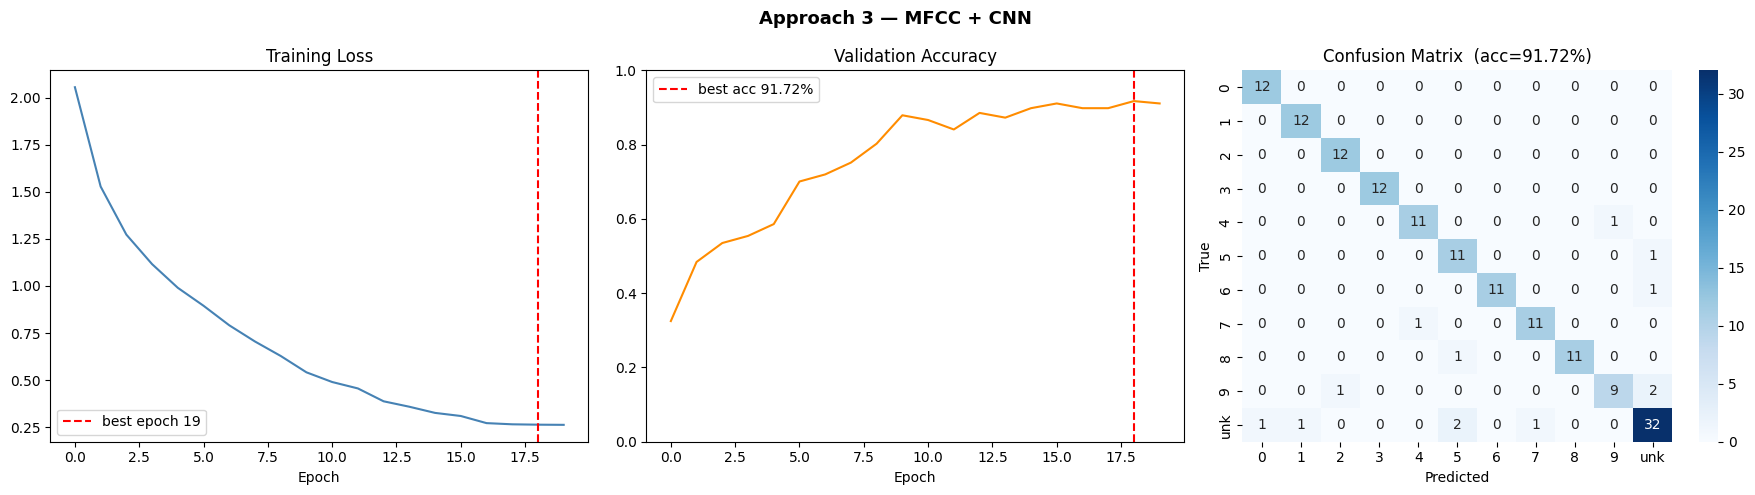

Saved: approach3_results.png


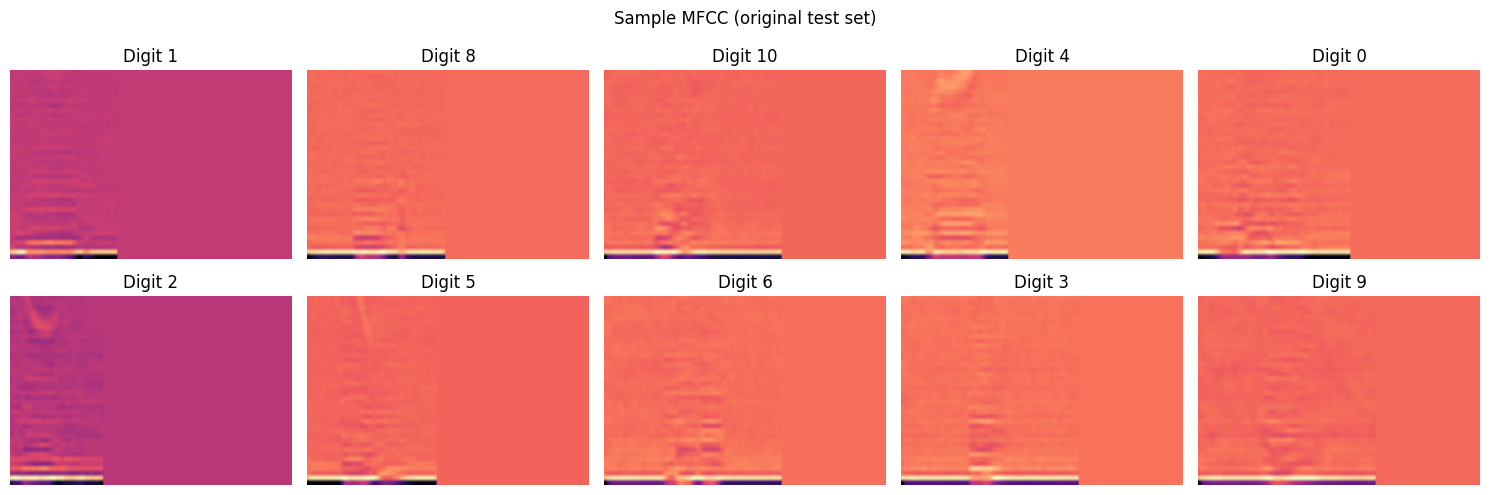

In [18]:
# ── Approach 3: Evaluation & Plots ───────────────────────────
model_a3.load_state_dict(torch.load(A3_MODEL_SAVE, map_location=device_a3))
trues_a3, preds_a3 = a3_evaluate(model_a3, test_dl_a3, device_a3)

target_names = [str(i) for i in range(10)] + ["unknown"]

print("=" * 50)
print(f"Final Val Accuracy: {accuracy_score(trues_a3, preds_a3):.4f}")
print(classification_report(trues_a3, preds_a3,
                            target_names=target_names[:NUM_CLASSES],
                            labels=list(range(NUM_CLASSES)),
                            zero_division=0))

cm_a3 = confusion_matrix(trues_a3, preds_a3, labels=list(range(NUM_CLASSES)))
plot_training(train_losses_a3, val_accs_a3, best_epoch_a3, best_acc_a3,
              cm_a3, "Approach 3 — MFCC + CNN",
              "approach3_results.png")

# MFCC sample grid
X_orig, y_orig = load_features_a3(split["test"][:50], split["test_labels"][:50])
fig2, axs = plt.subplots(2, 5, figsize=(15, 5))
shown = {}
for feat, label in zip(X_orig, y_orig):
    if label not in shown and len(shown) < 10:
        ax = axs.flat[len(shown)]
        ax.imshow(feat[0], aspect="auto", origin="lower", cmap="magma")
        ax.set_title(f"Digit {label}"); ax.axis("off")
        shown[label] = True
plt.suptitle("Sample MFCC (original test set)", fontsize=12)
plt.tight_layout()
plt.savefig("approach3_mfcc.png", dpi=150)
plt.show()
